In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [2]:
# carregando o conjunto bruto de avaliação (zero-day + controle BENIGN)
caminho_entrada = '../dados/dados_processados/zero_day/registros_avaliacao_zero_day_bruto.csv'
df_avaliacao = pd.read_csv(caminho_entrada)

print(f"Conjunto de avaliação carregado")
print(f"  Registros: {df_avaliacao.shape[0]:,}")
print(f"  Colunas:   {df_avaliacao.shape[1]}\n")

print("Distribuição das classes:")
print("=" * 50)
for classe, qtd in df_avaliacao['Label'].value_counts().items():
    pct = (qtd / len(df_avaliacao)) * 100
    print(f"  {classe:30s} → {qtd:>6,} ({pct:.2f}%)")
print("=" * 50)

Conjunto de avaliação carregado
  Registros: 147
  Colunas:   79

Distribuição das classes:
  BENIGN                         →    100 (68.03%)
  Infiltration                   →     36 (24.49%)
  Heartbleed                     →     11 (7.48%)


In [3]:
#  carregamos os transformadores JÁ TREINADOS na etapa de treino

pasta_modelos = '../modelos/'

# carregando o normalizador treinado (StandardScaler)
normalizador = joblib.load(os.path.join(pasta_modelos, 'normalizador.pkl'))
print(f"Normalizador carregado: {type(normalizador).__name__}")
print(f"  Features esperadas: {normalizador.n_features_in_}")

# carregando o PCA treinado (amostrado, 4 classes)
modelo_pca = joblib.load(os.path.join(pasta_modelos, 'modelo_pca.pkl'))
print(f"PCA carregado:    {type(modelo_pca).__name__}")
print(f"  Componentes: {modelo_pca.n_components_}")
print(f"  Variância explicada acumulada: {modelo_pca.explained_variance_ratio_.sum() * 100:.2f}%")

# carregando o LDA treinado (amostrado, 4 classes -> 3 componentes)
modelo_lda = joblib.load(os.path.join(pasta_modelos, 'modelo_lda.pkl'))
print(f"LDA carregado:    {type(modelo_lda).__name__}")
print(f"  Componentes: {modelo_lda.n_components}")

# carregando as features de referência a partir do CSV usado no treino
caminho_features_ref = '../dados/dados_processados/atributos_amostrados.csv'
df_ref = pd.read_csv(caminho_features_ref, nrows=1)
features_treino = list(df_ref.columns)
print(f"\nFeatures de referência carregadas: {len(features_treino)} colunas")
print(f"Primeiras 5: {features_treino[:5]}")
print(f"Últimas 5:   {features_treino[-5:]}")

Normalizador carregado: StandardScaler
  Features esperadas: 78
PCA carregado:    PCA
  Componentes: 15
  Variância explicada acumulada: 95.32%
LDA carregado:    LinearDiscriminantAnalysis
  Componentes: 3

Features de referência carregadas: 78 colunas
Primeiras 5: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
Últimas 5:   ['Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']


C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearDiscriminantAnalysis from ver

In [4]:
# separando features (X) e rótulo (y)
y_avaliacao = df_avaliacao['Label'].copy()
X_avaliacao = df_avaliacao.drop(columns=['Label']).copy()

print(f"Shape inicial de X: {X_avaliacao.shape}")
print(f"Shape inicial de y: {y_avaliacao.shape}\n")

# verificando se todas as features do treino estão presentes
features_faltantes = [f for f in features_treino if f not in X_avaliacao.columns]
features_extras = [f for f in X_avaliacao.columns if f not in features_treino]

print("Validação de compatibilidade de colunas:")
print("=" * 55)
print(f"  Features esperadas (do treino): {len(features_treino)}")
print(f"  Features faltantes no zero-day: {len(features_faltantes)}")
print(f"  Features extras no zero-day:    {len(features_extras)}")
print("=" * 55)

if features_faltantes:
    print(f"\n\u26a0\ufe0f ATEN\u00c7\u00c3O \u2014 features faltantes: {features_faltantes}")
if features_extras:
    print(f"\n\u2139\ufe0f Features extras (serão descartadas): {features_extras[:5]}...")

# garantindo a MESMA ordem e MESMAS colunas usadas no treino
X_avaliacao = X_avaliacao[features_treino]
print(f"\nShape final de X (alinhado ao treino): {X_avaliacao.shape}")

Shape inicial de X: (147, 78)
Shape inicial de y: (147,)

Validação de compatibilidade de colunas:
  Features esperadas (do treino): 78
  Features faltantes no zero-day: 0
  Features extras no zero-day:    0

Shape final de X (alinhado ao treino): (147, 78)


In [5]:
print("Aplicando normalização (StandardScaler)\n")

X_normalizado = normalizador.transform(X_avaliacao)

# convertendo de volta para DataFrame para facilitar inspeção
X_normalizado = pd.DataFrame(
    X_normalizado,
    columns=features_treino,
    index=X_avaliacao.index
)

print(f"Shape após normalização: {X_normalizado.shape}")
print(f"\nEstatísticas pós-normalização (primeiras 5 features):")
print(X_normalizado.iloc[:, :5].describe().round(3))

Aplicando normalização (StandardScaler)

Shape após normalização: (147, 78)

Estatísticas pós-normalização (primeiras 5 features):
       Destination Port  Flow Duration  Total Fwd Packets  \
count           147.000        147.000            147.000   
mean             -0.094          0.593              0.495   
std               0.917          1.389              1.309   
min              -0.456         -0.471             -0.012   
25%              -0.453         -0.471             -0.010   
50%              -0.434         -0.430             -0.008   
75%              -0.434          1.924              0.019   
max               2.929          2.935              6.939   

       Total Backward Packets  Total Length of Fwd Packets  
count                 147.000                      147.000  
mean                    0.323                        8.796  
std                     0.885                       37.795  
min                    -0.011                       -0.058  
25%           

In [6]:
# aplicando o PCA treinado (apenas .transform())
print("Aplicando redução de dimensionalidade \u2014 PCA\n")

X_pca = modelo_pca.transform(X_normalizado)

# convertendo para DataFrame
colunas_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=colunas_pca, index=X_normalizado.index)

print(f"Shape após PCA: {X_pca.shape}")
print(f"Variância explicada acumulada (do treino): {modelo_pca.explained_variance_ratio_.sum() * 100:.2f}%")
print(f"\nPrimeiras linhas:")
print(X_pca.head().round(3))

Aplicando redução de dimensionalidade — PCA

Shape após PCA: (147, 15)
Variância explicada acumulada (do treino): 95.32%

Primeiras linhas:
     PC1    PC2    PC3    PC4    PC5    PC6     PC7     PC8    PC9    PC10  \
0 -2.764 -2.191  2.605  0.848  0.576  0.378  -0.908   0.722  0.076  -0.368   
1 -4.433 -0.959 -0.936  0.015 -1.431 -0.316   0.819   0.340 -0.300  -0.181   
2 -0.815 -2.660  2.704 -0.882  5.570  8.879 -15.206  21.496  7.303  48.313   
3 -4.605 -0.384  0.401  0.054  0.492  0.289  -0.702   0.068 -0.635  -0.485   
4 -1.296 -2.736  1.280 -0.733  2.731  6.797 -11.221  16.464  6.123  40.297   

    PC11    PC12   PC13    PC14    PC15  
0 -0.779   0.381 -0.442  -1.618  -0.500  
1 -0.715   0.289  0.124   0.066  -1.022  
2 -7.730  19.524  8.328  16.632 -14.257  
3 -0.121   0.182 -0.187  -0.065   0.269  
4 -7.758  16.460  6.833  13.477 -13.074  


In [7]:
# aplicando o LDA treinado (apenas .transform())
print("Aplicando redução supervisionada \u2014 LDA\n")

X_lda = modelo_lda.transform(X_normalizado)

# convertendo para DataFrame
colunas_lda = [f'LD{i+1}' for i in range(X_lda.shape[1])]
X_lda = pd.DataFrame(X_lda, columns=colunas_lda, index=X_normalizado.index)

print(f"Shape após LDA: {X_lda.shape}")
print(f"Componentes LDA: {modelo_lda.n_components} (igual a n_classes_treino - 1 = 4 - 1 = 3)")
print(f"\nPrimeiras linhas:")
print(X_lda.head().round(3))

Aplicando redução supervisionada — LDA

Shape após LDA: (147, 3)
Componentes LDA: 3 (igual a n_classes_treino - 1 = 4 - 1 = 3)

Primeiras linhas:
       LD1     LD2      LD3
0   -4.541  -5.725    1.927
1    2.058  -1.394    1.173
2  637.198  74.399 -332.963
3   -4.060   0.524    0.202
4  513.438  65.256 -265.527


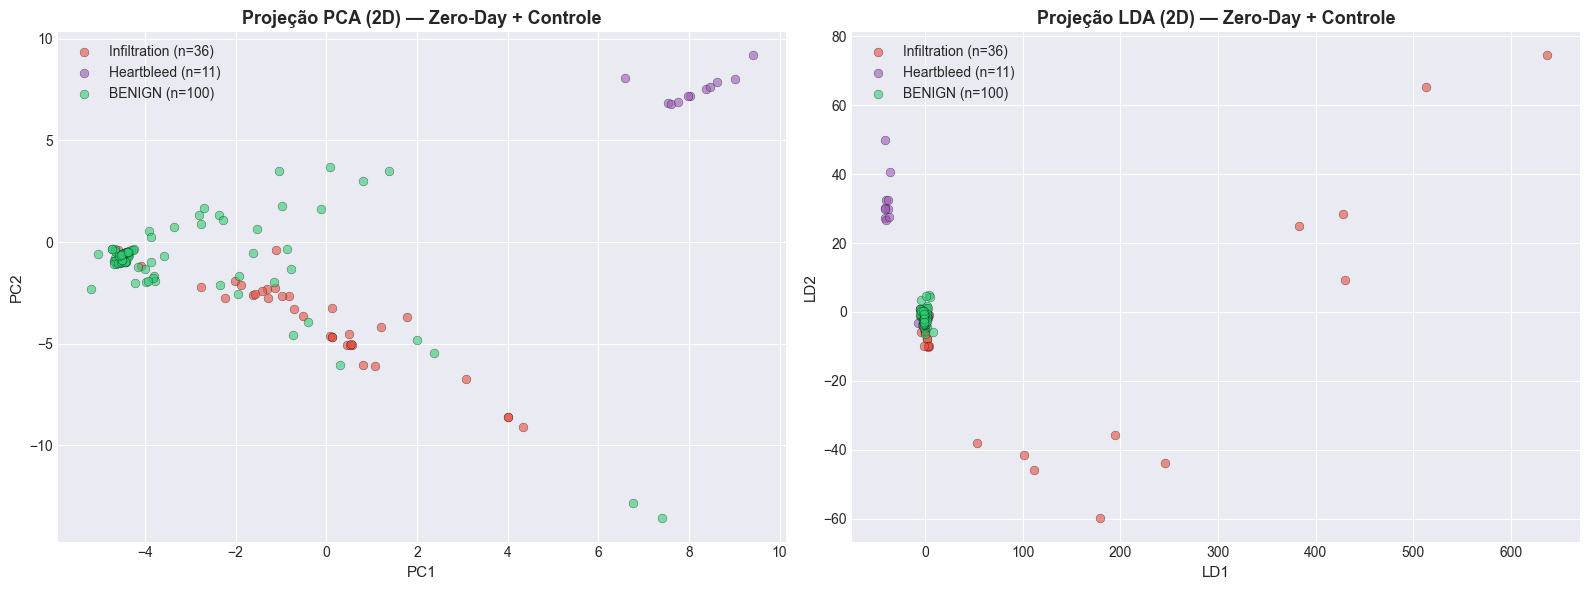

In [8]:
# visualizando como os pontos zero-day e BENIGN se distribuem no espaço reduzido
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mapa_cores = {
    'Heartbleed': '#9b59b6',
    'Infiltration': '#e74c3c',
    'BENIGN': '#2ecc71'
}

# PCA usando os 2 primeiros componentes
for classe in y_avaliacao.unique():
    mask = y_avaliacao == classe
    axes[0].scatter(
        X_pca.loc[mask, 'PC1'], X_pca.loc[mask, 'PC2'],
        c=mapa_cores.get(classe, '#95a5a6'),
        label=f'{classe} (n={mask.sum()})',
        alpha=0.6, s=40, edgecolor='black', linewidth=0.3
    )
axes[0].set_title('Projeção PCA (2D) \u2014 Zero-Day + Controle',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].legend(loc='best', fontsize=10)

# LDA  usando os 2 primeiros componentes
for classe in y_avaliacao.unique():
    mask = y_avaliacao == classe
    axes[1].scatter(
        X_lda.loc[mask, 'LD1'], X_lda.loc[mask, 'LD2'],
        c=mapa_cores.get(classe, '#95a5a6'),
        label=f'{classe} (n={mask.sum()})',
        alpha=0.6, s=40, edgecolor='black', linewidth=0.3
    )
axes[1].set_title('Projeção LDA (2D) \u2014 Zero-Day + Controle',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('LD1', fontsize=11)
axes[1].set_ylabel('LD2', fontsize=11)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
# salvando os três conjuntos prontos para serem usados no notebook 7.3
pasta_saida = '../dados/dados_processados/zero_day/'
os.makedirs(pasta_saida, exist_ok=True)

# 1) Conjunto normalizado (sem redução)
df_normalizado = X_normalizado.copy()
df_normalizado['Label'] = y_avaliacao.values
caminho_norm = os.path.join(pasta_saida, 'avaliacao_normalizado.csv')
df_normalizado.to_csv(caminho_norm, index=False)

# 2) Conjunto com PCA
df_pca = X_pca.copy()
df_pca['Label'] = y_avaliacao.values
caminho_pca = os.path.join(pasta_saida, 'avaliacao_pca.csv')
df_pca.to_csv(caminho_pca, index=False)

# 3) Conjunto com LDA
df_lda = X_lda.copy()
df_lda['Label'] = y_avaliacao.values
caminho_lda = os.path.join(pasta_saida, 'avaliacao_lda.csv')
df_lda.to_csv(caminho_lda, index=False)

# resumo
print("Arquivos salvos com sucesso:\n")
print("=" * 65)
for caminho, nome in [
    (caminho_norm, 'Normalizado'),
    (caminho_pca, 'PCA'),
    (caminho_lda, 'LDA')
]:
    kb = os.path.getsize(caminho) / 1024
    print(f"  [{nome:12s}] {caminho}")
    print(f"               Tamanho: {kb:.1f} KB\n")
print("=" * 65)

Arquivos salvos com sucesso:

  [Normalizado ] ../dados/dados_processados/zero_day/avaliacao_normalizado.csv
               Tamanho: 213.0 KB

  [PCA         ] ../dados/dados_processados/zero_day/avaliacao_pca.csv
               Tamanho: 43.5 KB

  [LDA         ] ../dados/dados_processados/zero_day/avaliacao_lda.csv
               Tamanho: 9.8 KB



In [10]:
print("=" * 65)
print("       RESUMO DO PRÉ-PROCESSAMENTO ZERO-DAY (7.2)")
print("=" * 65)
print(f"\n Registros processados:           {len(df_avaliacao):,}")
print(f"\n Transformações aplicadas:")
print("     \u2022 StandardScaler  (treinado no notebook de treino)")
print(f"     \u2022 PCA             ({modelo_pca.n_components_} componentes)")
print(f"     \u2022 LDA             ({modelo_lda.n_components} componentes)")
print(f"\n Conjuntos finais gerados:")
print(f"     \u2022 avaliacao_normalizado.csv  \u2192 shape {df_normalizado.shape}")
print(f"     \u2022 avaliacao_pca.csv          \u2192 shape {df_pca.shape}")
print(f"     \u2022 avaliacao_lda.csv          \u2192 shape {df_lda.shape}")
print(f"\n Distribuição por classe (mantida):")
for classe, qtd in y_avaliacao.value_counts().items():
    print(f"     \u2022 {classe:25s}: {qtd:,} registros")
print("\n" + "=" * 65)


       RESUMO DO PRÉ-PROCESSAMENTO ZERO-DAY (7.2)

 Registros processados:           147

 Transformações aplicadas:
     • StandardScaler  (treinado no notebook de treino)
     • PCA             (15 componentes)
     • LDA             (3 componentes)

 Conjuntos finais gerados:
     • avaliacao_normalizado.csv  → shape (147, 79)
     • avaliacao_pca.csv          → shape (147, 16)
     • avaliacao_lda.csv          → shape (147, 4)

 Distribuição por classe (mantida):
     • BENIGN                   : 100 registros
     • Infiltration             : 36 registros
     • Heartbleed               : 11 registros

